<p align="left">
  <a href="https://colab.research.google.com/github/wgomezf/analisis_datos/blob/main/02_Clasificación_lineal/kfoldmul.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" width="200">
  </a>
</p>

In [26]:
############################################################
# Autor: Wilfrido Gómez Flores (Cinvestav)                 #
# E-mail: wgomez@cinvestav.mx                              #
# Curso: Análisis de datos                                 #
# Tópico: Validación cruzada en clasificación multiclase   #
############################################################

Carga bibliotecas necesarias

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import KFold
from scipy.stats import rankdata

Instala y carga la biblioteca de LIBSVM

In [28]:
# https://github.com/cjlin1/libsvm
!pip install -q -U libsvm-official
from libsvm.svmutil import *

Carga el conjunto de datos Iris con 3 clases, 150 muestras y 4 variables

In [29]:
iris = load_iris()
df = pd.DataFrame(data=iris.data)
X = df.to_numpy() # Características
df = pd.DataFrame(data=iris.target)
Y = df.to_numpy() # Etiquetas de clase: 1,2 3
d = X.shape[1] # Número de variables
c = np.unique(Y).size # Número de clases
labels = iris.target_names # Etiquetas de clase

Función para el cálculo de índices de desempeño para clasificación multiclase

In [30]:
def mulclassperf(Y, Yp):
    c = np.unique(Y)
    k = len(c)
    C = np.zeros((k, k))

    for i in range(k):
        for j in range(k):
            C[i, j] = np.sum((Y == c[i]) & (Yp == c[j]))
    n = np.sum(C)
    tp = np.zeros(k)   # True positives
    tn = np.zeros(k)   # True negatives
    fp = np.zeros(k)   # False negatives
    fn = np.zeros(k)   # False positives

    for i in range(k):
        tp[i] = C[i, i]
        fp[i] = np.sum(C[i, :]) - C[i, i]
        fn[i] = np.sum(C[:, i]) - C[i, i]
        tn[i] = n - (tp[i] + fp[i] + fn[i])

    ACC = np.trace(C) / n # Exactitud global
    ACP = np.sum(tp + tn) / (n * k) # Exactitud promedio
    PRE = np.mean(tp / (tp + fp)) # Presicion
    SEN = np.mean(tp / (tp + fn)) # Sensibilidad
    SPE = np.mean(tn / (tn + fp)) # Especificidad
    F1S = (2 * PRE * SEN) / (PRE + SEN) # F1-score
    # MCC multiclase
    Skl_num = 0.0
    Skl_den1 = 0.0
    Skl_den2 = 0.0
    Ct = C.T
    for k_idx in range(k):
        for l_idx in range(k):
            Skl_num  = Skl_num  + np.sum(C[k_idx, :] * C[:, l_idx])
            Skl_den1 = Skl_den1 + np.sum(C[k_idx, :] * Ct[:, l_idx])
            Skl_den2 = Skl_den2 + np.sum(Ct[k_idx, :] * C[:, l_idx])
    MCC = (n * np.trace(C) - Skl_num) / (np.sqrt(n * n - Skl_den1) * np.sqrt(n * n - Skl_den2))
    Out = np.array([MCC, ACC, ACP, PRE, SEN, SPE, F1S]);
    return Out, C

Divide el conjunto de datos usando validación cruzada con 5 pliegues

In [31]:
K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

Itera sobre cada pliegue haciendo entrenamiento y prueba

In [32]:
# Parámetros de SVM
gamma = 0.001
C = 100
opt = '-q -s 0 -t 2 -c %f -g %f' % (C, gamma)

cm = np.zeros((3,3)) # Matriz de confusión
res = np.zeros(7) # Vector de resultados, changed from (8,1) to 8 for 1D array
for train_idx, test_idx in kf.split(X):
    # Divide en entrenamiento y prueba
    X_train, X_test = X[train_idx], X[test_idx]
    Y_train, Y_test = Y[train_idx], Y[test_idx]
    # Normaliza los conjuntos de datos
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    # Entrena SVM
    model = svm_train(Y_train.ravel().tolist(), X_train, opt)
    # Clasifica con SVM
    Y_pred, _, Y_scr = svm_predict(Y_test.ravel().tolist(), X_test, model, '-q')
    # Evalua desempeño de clasificación
    aux1, aux2 = mulclassperf(Y_test.ravel(), Y_pred)
    res += aux1
    cm += aux2
res = res/K # Promedio

# Imprime resultados
indice = ['MCC', 'ACC', 'ACP', 'PRE', 'SEN', 'SPE', 'F1s']
for i in range(len(res)):
    print('%s: %0.3f\n' % (indice[i], res[i]), end='')

MCC: 0.951
ACC: 0.967
ACP: 0.978
PRE: 0.964
SEN: 0.970
SPE: 0.984
F1s: 0.967


Visualiza matriz de confusión

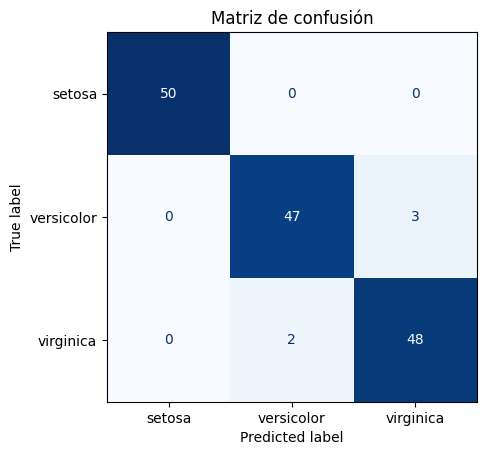

In [33]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(colorbar=False, cmap='Blues')
plt.title('Matriz de confusión')
plt.show()